# Final Data Preparation — TD–GC–MS (QC + Samples)

**Purpose**  
Prepare GC–MS peak tables for downstream analytics by cleaning QC/sample data, checking QC performance, correcting instrument drift, and producing normalized outputs.

**What this notebook does (high level)**  
- Loads input paths and parameters from a YAML config (Databricks/UC volumes).
- Cleans QC tables and prepares sample tables (retention time handling + ID filtering).
- Matches alkane standards to peak IDs to identify **stable peaks**.
- Merges QC peak intensities with master metadata to recover injection order / QC levels.
- Evaluates QC linearity and injection stability (LOESS + linear regression diagnostics).
- Applies **global LOESS drift correction** using stable peaks.
- Ranks QC runs based on corrected intensities.
- Normalizes samples using the QC4 mean reference and returns **wide + long** normalized datasets.

**Inputs (from config + master data)**  
- `config_mixed.yaml` (QC + sample paths, parameters, allowed sample IDs)  
- Raw QC Excel file  
- Raw sample file  
- Master metadata CSV (injection order / sample annotations)

**Outputs**  
- Cleaned QC table  
- Drift-corrected tables: corrected QC + evaluation summaries  
- QC ranking table  
- Normalized datasets (wide + long), saved to the configured output directory

In [0]:
%pip install -U openpyxl

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import matplotlib; matplotlib.use('inline')
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import subprocess; subprocess.check_call(["python", "-m", "pip", "install", "networkx"])  
import networkx as nx
from statsmodels.nonparametric.smoothers_lowess import lowess
import yaml
import os, importlib.util
import subprocess; subprocess.check_call(["python", "-m", "pip", "install", "dash"]); import dash


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


  Using cached dash-4.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached retrying-1.4.2-py3-none-any.whl.metadata (5.5 kB)
Using cached dash-4.0.0-py3-none-any.whl (7.2 MB)
Using cached retrying-1.4.2-py3-none-any.whl (10 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Load QC data using path from config

In [0]:


CONFIG_PATH = "/Volumes/bmqg/default_bronze/fatemeh/config_mixed.yaml"

txt = "\n".join([r["value"] for r in spark.read.text(CONFIG_PATH).collect()])
config = yaml.safe_load(txt)

print("config keys:", list(config.keys()))


config keys: ['paths', 'qc', 'sample', 'data_paths', 'parameters', 'settings', 'data']


In [0]:
import sys
sys.path.append("/Workspace/Users/fatemeh.monfared@hzpc.com/aroma_flavor_project/final_flavor_project")

import data_prepration as dp


# Load and clean QCs

In [0]:
%pip install openpyxl
import pandas as pd

qc_cfg = config["qc"]
qc_input_path = qc_cfg["input_file_newharvested"]
qc_output_path = qc_cfg["output_file_newharvested"]

qc_data_mixed = pd.read_excel(
    qc_input_path,
    sheet_name=qc_cfg["sheet_name"],
    header=qc_cfg["header_row"],
    engine="openpyxl"
)

cleaned_qc_mixed, t1_cols = dp.clean_qc_data(
    qc_data_mixed,
    save_path=qc_output_path
)

print("QC saved to:", qc_output_path)
display(cleaned_qc_mixed.head())

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
 Extracted T1 columns: 64
Filtered DataFrame shape: (364, 69)
Mean |avg(tR1,tR2) - tR|: 0.000253
Max  |avg(tR1,tR2) - tR|: 0.000500
 Cleaned QC data saved to: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/cleaned_qc_mixed.csv
QC saved to: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/cleaned_qc_mixed.csv


Peak,tR_best,m/z,s1 S962_QC4_B1_D3_T1,s2 S962_QC1_B1_D10_T1,s3 S962_QC1_B1_D11_T1,s4 S962_QC1_B1_D12_T1,s5 S962_QC1_B1_D13_T1,s6 S962_QC1_B1_D14_T1,s7 S962_QC1_B1_D15_T1,s8 S962_QC1_B1_D16_T1,s9 S962_QC1_B1_D1_T1,s10 S962_QC1_B1_D2_T1,s11 S962_QC1_B1_D3_T1,s12 S962_QC1_B1_D4_T1,s13 S962_QC1_B1_D5_T1,s14 S962_QC1_B1_D6_T1,s15 S962_QC1_B1_D7_T1,s16 S962_QC1_B1_D8_T1,s17 S962_QC1_B1_D9_T1,s18 S962_QC2_B1_D10_T1,s19 S962_QC2_B1_D11_T1,s20 S962_QC2_B1_D12_T1,s21 S962_QC2_B1_D13_T1,s22 S962_QC2_B1_D14_T1,s23 S962_QC2_B1_D15_T1,s24 S962_QC2_B1_D16_T1,s25 S962_QC2_B1_D1_T1,s26 S962_QC2_B1_D2_T1,s27 S962_QC2_B1_D3_T1,s28 S962_QC2_B1_D4_T1,s29 S962_QC2_B1_D5_T1,s30 S962_QC2_B1_D6_T1,s31 S962_QC2_B1_D7_T1,s32 S962_QC2_B1_D8_T1,s33 S962_QC2_B1_D9_T1,s34 S962_QC3_B1_D10_T1,s35 S962_QC3_B1_D11_T1,s36 S962_QC3_B1_D12_T1,s37 S962_QC3_B1_D13_T1,s38 S962_QC3_B1_D14_T1,s39 S962_QC3_B1_D15_T1,s40 S962_QC3_B1_D16_T1,s41 S962_QC3_B1_D1_T1,s42 S962_QC3_B1_D2_T1,s43 S962_QC3_B1_D3_T1,s44 S962_QC3_B1_D4_T1,s45 S962_QC3_B1_D5_T1,s46 S962_QC3_B1_D6_T1,s47 S962_QC3_B1_D7_T1,s48 S962_QC3_B1_D8_T1,s49 S962_QC3_B1_D9_T1,s50 S962_QC4_B1_D10_T1,s51 S962_QC4_B1_D11_T1,s52 S962_QC4_B1_D12_T1,s53 S962_QC4_B1_D13_T1,s54 S962_QC4_B1_D14_T1,s55 S962_QC4_B1_D15_T1,s56 S962_QC4_B1_D16_T1,s57 S962_QC4_B1_D1_T1,s58 S962_QC4_B1_D2_T1,s59 S962_QC4_B1_D4_T1,s60 S962_QC4_B1_D5_T1,s61 S962_QC4_B1_D6_T1,s62 S962_QC4_B1_D7_T1,s63 S962_QC4_B1_D8_T1,s64 S962_QC4_B1_D9_T1
1,1.9215,40,32640,14216,40024,14216,34120,36432,14216,14216,14216,14216,31592,30392,29680,58056,54088,14216,14216,43168,39280,39776,33184,35424,14216,40160,33240,32304,30088,29200,28784,55848,51208,41024,14216,45136,43776,41128,14216,36048,49328,14216,34624,32592,29176,29432,28432,14216,53552,43584,47800,46112,42536,39232,34752,37064,37864,50232,14216,14216,30569,30832,14216,54128,41696,51224
2,1.9874999999999998,44,232076,869330,547161,223503,477024,227323,409379,898844,226214,536875,225821,449918,451128,784053,1033753,266082,776892,642995,505233,585674,224561,485760,413165,889437,890151,225292,439936,434243,493664,724573,273655,848579,303450,268676,612880,707500,294821,276992,474956,497423,247656,256706,446828,234825,514060,710295,297332,870523,902748,265557,603726,231047,238193,255366,449278,443548,237380,608224,464694,450409,246317,283874,269156,1206441
3,2.0345,64,115162,580289,114299,156040,135719,129249,107100,388496,64635,132648,116704,138230,122970,256250,247870,190232,204616,150655,107589,124465,132014,129659,99182,385094,91207,122204,108509,130189,149124,195963,244075,166214,272538,133289,106203,126944,209307,241305,87955,588687,92459,137465,114522,111302,110473,198612,220784,179566,175582,148131,152146,117343,140665,106704,99325,615043,112475,149746,99446,96558,187389,239667,179143,249495
4,2.1005000000000003,60,29889,41956,21726,11979,21044,10348,23143,35159,9283,6861,13675,19553,10544,33056,6291,5007,9837,17361,24377,13259,14014,23671,24537,39251,14248,8026,12864,19825,16655,32094,7456,8284,27930,40745,30067,27781,17487,29907,35762,66164,21026,25686,22757,23028,18876,43423,10052,12159,32707,35094,27415,12708,15224,25697,20450,68958,26406,14198,30641,32775,53760,10886,5663,23335
5,2.1825,93,89611,72826,89829,52266,70511,63367,87063,163236,34591,22594,43017,51303,38202,137691,35396,22849,46636,84293,95135,57421,64110,89482,70599,234817,57610,54443,58547,86178,77201,117127,47706,54765,117690,193776,209521,213277,149103,180194,238027,464950,121936,120342,109784,88096,110098,171158,166294,114863,195080,296123,213595,90645,86368,205036,179061,519477,72155,49911,131608,92073,118944,71105,23681,163466


# Data prepration module importing

In [0]:
import importlib.util
import sys
import os

DP_PATH = "/Workspace/Users/fatemeh.monfared@hzpc.com/aroma_flavor_project/final_flavor_project/data_prepration.py"

assert os.path.exists(DP_PATH), f" data_preparation.py not found: {DP_PATH}"

spec = importlib.util.spec_from_file_location("data_preparation", DP_PATH)
dp = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dp)

print(" data_preparation loaded from:", DP_PATH)
print("Functions:", [f for f in dir(dp) if not f.startswith("_")])


 data_preparation loaded from: /Workspace/Users/fatemeh.monfared@hzpc.com/aroma_flavor_project/final_flavor_project/data_prepration.py
Functions: ['Counter', 'Dash', 'Input', 'LinearRegression', 'Output', 'analyze_qc_intensity_stability', 'assess_stable_peak_injection_order_trend', 'average_gcms_intensities_by_variety', 'clean_qc_data', 'dcc', 'global_drift_correction', 'go', 'html', 'linregress', 'load_sample_data', 'lowess', 'make_subplots', 'match_alkanes_to_peaks', 'merge_qc_peak_intensities_with_metadata', 'normalize_with_qc4_meaned_samples', 'np', 'pd', 'plot_alkane_matches', 'plot_injection_stability_loess', 'plot_qc_injection_stability_linear', 'plt', 'prepare_and_clean_potato_data', 'rank_qcs', 're', 'run_qc_trend_dashboard', 'sns']


# Load sample 

In [0]:
import os

# =========================================================
# 1) READ FROM CONFIG (NO HARDCODE)
# =========================================================
sample_cfg = config["sample"]
data_cfg   = config["data_paths"]

input_path = sample_cfg["input_file_newharvested"]


sample_rows = sample_cfg.get("header_row", 50)

assert os.path.exists(input_path), f"❌ Sample input not found: {input_path}"

# =========================================================
# 2) SAFETY CHECK
# =========================================================
if not hasattr(dp, "load_sample_data"):
    raise AttributeError("❌ data_preparation.py has no function named load_sample_data")

# =========================================================
# 3) CALL FUNCTION (MATCHES MODULE SIGNATURE)
# =========================================================
sample_data, header_row_detected = dp.load_sample_data(
    input_path=input_path,
    sample_rows=sample_rows
)

print("Header row detected:", header_row_detected)
print("Sample data shape:", sample_data.shape)
display(sample_data.head())


 Header row taken from config: 12


,Peak,tR1,tR2,tR,m/z,ID Names,s1 S962_100_B1_D9_T1,s2 S962_100_B1_D9_T2,s3 S962_101_B1_D9_T1,s4 S962_101_B1_D9_T2,s5 S962_102_B1_D9_T1,s6 S962_102_B1_D9_T2,s7 S962_103_B1_D9_T1,s8 S962_103_B1_D9_T2,s9 S962_104_B1_D9_T1,s10 S962_104_B1_D9_T2,s11 S962_105_B1_D9_T1,s12 S962_105_B1_D9_T2,s13 S962_106_B1_D9_T1,s14 S962_106_B1_D9_T2,s15 S962_107_B1_D9_T1,s16 S962_107_B1_D9_T2,s17 S962_108_B1_D9_T1,s18 S962_108_B1_D9_T2,s19 S962_109_B1_D10_T1,s20 S962_109_B1_D10_T2,s21 S962_10_B1_D1_T1,s22 S962_10_B1_D1_T2,s23 S962_110_B1_D10_T1,s24 S962_110_B1_D10_T2,s25 S962_111_B1_D10_T1,s26 S962_111_B1_D10_T2,s27 S962_112_B1_D10_T1,s28 S962_112_B1_D10_T2,s29 S962_113_B1_D10_T1,s30 S962_114_B1_D10_T1,s31 S962_114_B1_D10_T2,s32 S962_115_B1_D10_T1,s33 S962_116_B1_D10_T1,s34 S962_117_B1_D10_T1,...,s337 S962_82_B1_D7_T1,s338 S962_82_B1_D7_T2,s339 S962_83_B1_D7_T1,s340 S962_83_B1_D7_T2,s341 S962_84_B1_D7_T1,s342 S962_84_B1_D7_T2,s343 S962_85_B1_D8_T1,s344 S962_85_B1_D8_T2,s345 S962_86_B1_D8_T1,s346 S962_86_B1_D8_T2,s347 S962_87_B1_D8_T1,s348 S962_87_B1_D8_T2,s349 S962_88_B1_D8_T1,s350 S962_88_B1_D8_T2,s351 S962_89_B1_D8_T1,s352 S962_89_B1_D8_T2,s353 S962_8_B1_D1_T1,s354 S962_8_B1_D1_T2,s355 S962_90_B1_D8_T1,s356 S962_90_B1_D8_T2,s357 S962_91_B1_D8_T1,s358 S962_91_B1_D8_T2,s359 S962_92_B1_D8_T1,s360 S962_92_B1_D8_T2,s361 S962_93_B1_D8_T1,s362 S962_93_B1_D8_T2,s363 S962_94_B1_D8_T1,s364 S962_94_B1_D8_T2,s365 S962_95_B1_D8_T1,s366 S962_95_B1_D8_T2,s367 S962_96_B1_D8_T1,s368 S962_96_B1_D8_T2,s369 S962_97_B1_D9_T1,s370 S962_97_B1_D9_T2,s371 S962_98_B1_D9_T1,s372 S962_98_B1_D9_T2,s373 S962_99_B1_D9_T1,s374 S962_99_B1_D9_T2,s375 S962_9_B1_D1_T1,s376 S962_9_B1_D1_T2
0,1,1.883,1.966,1.925,40,0.34% || 40 ...,46840,42688,45312,43216,40264,45792,45016,45440,42496,42976,43384,43640,40136,43288,44696,44920,43624,39312,41680,39664,34976,30840,40744,40504,42112,39144,41096,38480,41880,42608,34976,43784,38672,43320,...,52784,53600,55080,52432,53472,52936,44840,45296,44232,46200,44352,46976,43712,48168,43296,47680,32896,33912,43640,46712,44216,46048,45608,45672,47832,43752,46232,47896,46616,44264,46992,47376,52968,14088,45656,41648,42528,44376,32912,35016
1,2,1.947,2.044,1.995,44,7.20% || 44 81 96 ...,1094642,1085499,1004242,1075727,1005255,1049372,1228681,1154319,1154675,1091724,1146265,1028840,1016607,1116444,1051112,1077376,999601,1028045,936329,925570,760643,542197,896098,888695,820354,1011518,1028420,991787,935536,891693,1054888,949665,964932,1030694,...,1275613,1187713,1247498,1292400,1189025,1215422,1108635,1035740,1187283,1201572,1105669,1029055,1213895,1159228,1027778,1026647,778771,658326,989869,1032676,1080541,1095883,1136761,1059945,986464,1092250,1091870,1153757,1048469,1013826,1103667,1026562,1296326,270242,1058618,992038,1159084,1032778,778253,708911
2,3,1.977,2.117,2.047,64,7.42% || 64 48 66 50 ...,1019641,984040,713366,1068503,844203,870789,1132415,993071,1000900,866734,1398663,808335,1129511,925314,820079,851981,909198,765648,878676,848544,378350,383202,742336,792988,730535,887973,993995,1232042,782768,1016050,809601,824371,1060353,1099416,...,959419,866153,1186607,883866,1221403,759365,590929,662165,517336,495608,876189,481864,619417,677181,902996,814440,534231,445202,765813,770888,1212517,1176489,755004,874315,739709,712592,1039287,1216636,1178902,924324,1048474,869612,1117760,1022447,1121466,853487,1180373,849523,666032,1006861
3,4,2.009,2.129,2.069,47,0.56% || 47 65 46 49 ...,61115,139457,51365,111277,88098,121336,89275,114281,109438,100214,90795,74283,63167,88214,78645,83291,68489,77348,67683,65248,37993,42486,55513,71640,88339,144447,133556,137004,64431,62768,59906,62449,76587,87287,...,100669,85384,117906,133199,80067,80484,53550,81907,40905,53110,120552,97662,101865,121765,84722,96273,27191,24524,67897,57442,96457,106436,51503,55830,70109,71013,113020,110948,112147,95782,128723,107726,106886,66104,58004,75519,83131,81849,37053,43987
4,5,2.074,2.148,2.111,157,0.29% || 157 207 226 145 176 ...,32978,130493,60603,21205,13676,13719,86670,45213,10815

Header row detected: 12
Sample data shape: (424, 382)


Peak,tR1,tR2,tR,m/z,ID Names,s1 S962_100_B1_D9_T1,s2 S962_100_B1_D9_T2,s3 S962_101_B1_D9_T1,s4 S962_101_B1_D9_T2,s5 S962_102_B1_D9_T1,s6 S962_102_B1_D9_T2,s7 S962_103_B1_D9_T1,s8 S962_103_B1_D9_T2,s9 S962_104_B1_D9_T1,s10 S962_104_B1_D9_T2,s11 S962_105_B1_D9_T1,s12 S962_105_B1_D9_T2,s13 S962_106_B1_D9_T1,s14 S962_106_B1_D9_T2,s15 S962_107_B1_D9_T1,s16 S962_107_B1_D9_T2,s17 S962_108_B1_D9_T1,s18 S962_108_B1_D9_T2,s19 S962_109_B1_D10_T1,s20 S962_109_B1_D10_T2,s21 S962_10_B1_D1_T1,s22 S962_10_B1_D1_T2,s23 S962_110_B1_D10_T1,s24 S962_110_B1_D10_T2,s25 S962_111_B1_D10_T1,s26 S962_111_B1_D10_T2,s27 S962_112_B1_D10_T1,s28 S962_112_B1_D10_T2,s29 S962_113_B1_D10_T1,s30 S962_114_B1_D10_T1,s31 S962_114_B1_D10_T2,s32 S962_115_B1_D10_T1,s33 S962_116_B1_D10_T1,s34 S962_117_B1_D10_T1,s35 S962_117_B1_D10_T2,s36 S962_118_B1_D10_T1,s37 S962_119_B1_D10_T1,s38 S962_119_B1_D10_T2,s39 S962_11_B1_D1_T1,s40 S962_11_B1_D1_T2,s41 S962_120_B1_D10_T1,s42 S962_120_B1_D10_T2,s43 S962_121_B1_D11_T1,s44 S962_121_B1_D11_T2,s45 S962_122_B1_D11_T1,s46 S962_122_B1_D11_T2,s47 S962_123_B1_D11_T1,s48 S962_123_B1_D11_T2,s49 S962_124_B1_D11_T1,s50 S962_124_B1_D11_T2,s51 S962_125_B1_D11_T1,s52 S962_125_B1_D11_T2,s53 S962_126_B1_D11_T1,s54 S962_126_B1_D11_T2,s55 S962_127_B1_D11_T1,s56 S962_127_B1_D11_T2,s57 S962_128_B1_D11_T1,s58 S962_128_B1_D11_T2,s59 S962_129_B1_D11_T1,s60 S962_129_B1_D11_T2,s61 S962_12_B1_D1_T1,s62 S962_12_B1_D1_T2,s63 S962_130_B1_D11_T1,s64 S962_130_B1_D11_T2,s65 S962_131_B1_D11_T1,s66 S962_131_B1_D11_T2,s67 S962_132_B1_D11_T1,s68 S962_132_B1_D11_T2,s69 S962_133_B1_D12_T1,s70 S962_133_B1_D12_T2,s71 S962_134_B1_D12_T1,s72 S962_134_B1_D12_T2,s73 S962_135_B1_D12_T1,s74 S962_135_B1_D12_T2,s75 S962_136_B1_D12_T1,s76 S962_136_B1_D12_T2,s77 S962_137_B1_D12_T1,s78 S962_137_B1_D12_T2,s79 S962_138_B1_D12_T1,s80 S962_138_B1_D12_T2,s81 S962_139_B1_D12_T1,s82 S962_139_B1_D12_T2,s83 S962_13_B1_D2_T1,s84 S962_13_B1_D2_T2,s85 S962_140_B1_D12_T1,s86 S962_140_B1_D12_T2,s87 S962_141_B1_D12_T1,s88 S962_141_B1_D12_T2,s89 S962_142_B1_D12_T1,s90 S962_142_B1_D12_T2,s91 S962_143_B1_D12_T1,s92 S962_143_B1_D12_T2,s93 S962_144_B1_D12_T1,s94 S962_144_B1_D12_T2,s95 S962_145_B1_D13_T1,s96 S962_145_B1_D13_T2,s97 S962_146_B1_D13_T1,s98 S962_146_B1_D13_T2,s99 S962_147_B1_D13_T1,s100 S962_147_B1_D13_T2,s101 S962_148_B1_D13_T1,s102 S962_148_B1_D13_T2,s103 S962_149_B1_D13_T1,s104 S962_149_B1_D13_T2,s105 S962_14_B1_D2_T1,s106 S962_14_B1_D2_T2,s107 S962_150_B1_D13_T1,s108 S962_150_B1_D13_T2,s109 S962_151_B1_D13_T1,s110 S962_151_B1_D13_T2,s111 S962_152_B1_D13_T1,s112 S962_152_B1_D13_T2,s113 S962_153_B1_D13_T1,s114 S962_153_B1_D13_T2,s115 S962_154_B1_D13_T1,s116 S962_154_B1_D13_T2,s117 S962_155_B1_D13_T1,s118 S962_155_B1_D13_T2,s119 S962_156_B1_D13_T1,s120 S962_156_B1_D13_T2,s121 S962_157_B1_D14_T1,s122 S962_157_B1_D14_T2,s123 S962_158_B1_D14_T1,s124 S962_158_B1_D14_T2,s125 S962_159_B1_D14_T1,s126 S962_159_B1_D14_T2,s127 S962_15_B1_D2_T1,s128 S962_15_B1_D2_T2,s129 S962_160_B1_D14_T1,s130 S962_160_B1_D14_T2,s131 S962_161_B1_D14_T1,s132 S962_161_B1_D14_T2,s133 S962_162_B1_D14_T1,s134 S962_162_B1_D14_T2,s135 S962_163_B1_D14_T1,s136 S962_163_B1_D14_T2,s137 S962_164_B1_D14_T1,s138 S962_164_B1_D14_T2,s139 S962_165_B1_D14_T1,s140 S962_165_B1_D14_T2,s141 S962_166_B1_D14_T1,s142 S962_166_B1_D14_T2,s143 S962_167_B1_D14_T1,s144 S962_167_B1_D14_T2,s145 S962_168_B1_D14_T1,s146 S962_168_B1_D14_T2,s147 S962_169_B1_D15_T1,s148 S962_169_B1_D15_T2,s149 S962_16_B1_D2_T1,s150 S962_16_B1_D2_T2,s151 S962_170_B1_D15_T1,s152 S962_170_B1_D15_T2,s153 S962_171_B1_D15_T1,s154 S962_171_B1_D15_T2,s155 S962_172_B1_D15_T1,s156 S962_172_B1_D15_T2,s157 S962_173_B1_D15_T1,s158 S962_173_B1_D15_T2,s159 S962_174_B1_D15_T1,s160 S962_174_B1_D15_T2,s161 S962_175_B1_D15_T1,s162 S962_175_B1_D15_T2,s163 S962_176_B1_D15_T1,s164 S962_176_B1_D15_T2,s165 S962_177_B1_D15_T1,s166 S962_177_B1_D15_T2,s167 S962_178_B1_D15_T1,s168 S962_178_B1_D15_T2,s169 S962_179_B1_D15_T1,s170 S962_179_B1_D15_T2,s171 S962_17_B1_D2_T1,s172 S962_17_B1_D2_T2,s

#  Sample Data Preprocessing: Potato Data Cleaning and Retention Time Averaging

In [0]:
import os
import pandas as pd

# =========================================================
# 1) READ FROM CONFIG
# =========================================================
sample_cfg = config["sample"]
data_cfg = config["data_paths"]

input_path = sample_cfg["input_file_newharvested"]
output_path = sample_cfg["output_file_newharvested"]  # df_corrected.csv

# save 
selected_mixed_data, diffs = dp.prepare_and_clean_potato_data(
    input_path=input_path,
    final_normalized_ids=data_cfg["final_normalized_ids_newharvestd"],
    output_path=None
)


selected_mixed_data.to_csv(output_path, index=False)

print("Saved to:", output_path)

# =========================================================
# 2) QUICK CHECK
# =========================================================
print("Selected data shape:", selected_mixed_data.shape)
print("Dropped / mismatched IDs:", diffs)

display(selected_mixed_data.head())

assert os.path.exists(output_path), f" Output file not found: {output_path}"

df = pd.read_csv(output_path)
print("Reloaded shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

 2 sample IDs were not found in the dataset.
Example missing IDs: ['S962_85_B1_D9_T2', 'SS962_176_B1_D15_T2']

Retention Time Differences Summary:
abs(tR - tR1):
 count    424.000000
mean       0.123111
std        0.094628
min        0.015000
25%        0.059000
50%        0.099000
75%        0.159500
max        0.726000
dtype: float64 

abs(tR - tR2):
 count    424.000000
mean       0.123071
std        0.094598
min        0.016000
25%        0.060000
50%        0.098500
75%        0.158750
max        0.726000
dtype: float64 

abs(tR1 - tR2):
 count    424.000000
mean       0.246182
std        0.189224
min        0.031000
25%        0.119000
50%        0.197500
75%        0.318250
max        1.452000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    424.000000
mean       0.000251
std        0.000250
min        0.000000
25%        0.000000
50%        0.000500
75%        0.000500
max        0.000500
dtype: float64 

 Final dataset shape: (424, 191)
Saved to: /Volumes/bmqg/default_bronze

Peak,tR_best,m/z,s199 S962_1_B1_D1_T1,s221 S962_2_B1_D1_T1,s243 S962_3_B1_D1_T1,s265 S962_4_B1_D1_T1,s287 S962_5_B1_D1_T1,s309 S962_6_B1_D1_T1,s331 S962_7_B1_D1_T1,s353 S962_8_B1_D1_T1,s375 S962_9_B1_D1_T1,s21 S962_10_B1_D1_T1,s39 S962_11_B1_D1_T1,s61 S962_12_B1_D1_T1,s83 S962_13_B1_D2_T1,s105 S962_14_B1_D2_T1,s127 S962_15_B1_D2_T1,s149 S962_16_B1_D2_T1,s171 S962_17_B1_D2_T1,s193 S962_18_B1_D2_T1,s197 S962_19_B1_D2_T1,s201 S962_20_B1_D2_T1,s203 S962_21_B1_D2_T1,s205 S962_22_B1_D2_T1,s207 S962_23_B1_D2_T1,s209 S962_24_B1_D2_T1,s211 S962_25_B1_D3_T1,s213 S962_26_B1_D3_T1,s215 S962_27_B1_D3_T1,s217 S962_28_B1_D3_T1,s219 S962_29_B1_D3_T1,s223 S962_30_B1_D3_T1,s225 S962_31_B1_D3_T1,s227 S962_32_B1_D3_T1,s229 S962_33_B1_D3_T1,s231 S962_34_B1_D3_T1,s233 S962_35_B1_D3_T1,s235 S962_36_B1_D3_T1,s237 S962_37_B1_D4_T1,s239 S962_38_B1_D4_T1,s241 S962_39_B1_D4_T1,s245 S962_40_B1_D4_T1,s247 S962_41_B1_D4_T1,s249 S962_42_B1_D4_T1,s251 S962_43_B1_D4_T1,s253 S962_44_B1_D4_T1,s255 S962_45_B1_D4_T1,s257 S962_46_B1_D4_T1,s259 S962_47_B1_D4_T1,s261 S962_48_B1_D4_T1,s263 S962_49_B1_D5_T1,s267 S962_50_B1_D5_T1,s269 S962_51_B1_D5_T1,s271 S962_52_B1_D5_T1,s273 S962_53_B1_D5_T1,s275 S962_54_B1_D5_T1,s277 S962_55_B1_D5_T1,s279 S962_56_B1_D5_T1,s281 S962_57_B1_D5_T1,s283 S962_58_B1_D5_T1,s285 S962_59_B1_D5_T1,s289 S962_60_B1_D5_T1,s291 S962_61_B1_D6_T1,s293 S962_62_B1_D6_T1,s295 S962_63_B1_D6_T1,s297 S962_64_B1_D6_T1,s299 S962_65_B1_D6_T1,s301 S962_66_B1_D6_T1,s303 S962_67_B1_D6_T1,s305 S962_68_B1_D6_T1,s307 S962_69_B1_D6_T1,s311 S962_70_B1_D6_T1,s313 S962_71_B1_D6_T1,s315 S962_72_B1_D6_T1,s317 S962_73_B1_D7_T1,s319 S962_74_B1_D7_T1,s321 S962_75_B1_D7_T1,s323 S962_76_B1_D7_T1,s325 S962_77_B1_D7_T1,s327 S962_78_B1_D7_T1,s329 S962_79_B1_D7_T1,s333 S962_80_B1_D7_T1,s335 S962_81_B1_D7_T1,s337 S962_82_B1_D7_T1,s339 S962_83_B1_D7_T1,s341 S962_84_B1_D7_T1,s345 S962_86_B1_D8_T1,s347 S962_87_B1_D8_T1,s349 S962_88_B1_D8_T1,s351 S962_89_B1_D8_T1,s355 S962_90_B1_D8_T1,s357 S962_91_B1_D8_T1,s359 S962_92_B1_D8_T1,s361 S962_93_B1_D8_T1,s363 S962_94_B1_D8_T1,s365 S962_95_B1_D8_T1,s367 S962_96_B1_D8_T1,s369 S962_97_B1_D9_T1,s371 S962_98_B1_D9_T1,s373 S962_99_B1_D9_T1,s1 S962_100_B1_D9_T1,s3 S962_101_B1_D9_T1,s5 S962_102_B1_D9_T1,s7 S962_103_B1_D9_T1,s9 S962_104_B1_D9_T1,s11 S962_105_B1_D9_T1,s13 S962_106_B1_D9_T1,s15 S962_107_B1_D9_T1,s17 S962_108_B1_D9_T1,s19 S962_109_B1_D10_T1,s23 S962_110_B1_D10_T1,s25 S962_111_B1_D10_T1,s27 S962_112_B1_D10_T1,s29 S962_113_B1_D10_T1,s30 S962_114_B1_D10_T1,s32 S962_115_B1_D10_T1,s33 S962_116_B1_D10_T1,s34 S962_117_B1_D10_T1,s36 S962_118_B1_D10_T1,s37 S962_119_B1_D10_T1,s41 S962_120_B1_D10_T1,s43 S962_121_B1_D11_T1,s45 S962_122_B1_D11_T1,s47 S962_123_B1_D11_T1,s49 S962_124_B1_D11_T1,s51 S962_125_B1_D11_T1,s53 S962_126_B1_D11_T1,s55 S962_127_B1_D11_T1,s57 S962_128_B1_D11_T1,s59 S962_129_B1_D11_T1,s63 S962_130_B1_D11_T1,s65 S962_131_B1_D11_T1,s67 S962_132_B1_D11_T1,s69 S962_133_B1_D12_T1,s71 S962_134_B1_D12_T1,s73 S962_135_B1_D12_T1,s75 S962_136_B1_D12_T1,s77 S962_137_B1_D12_T1,s79 S962_138_B1_D12_T1,s81 S962_139_B1_D12_T1,s85 S962_140_B1_D12_T1,s87 S962_141_B1_D12_T1,s89 S962_142_B1_D12_T1,s91 S962_143_B1_D12_T1,s93 S962_144_B1_D12_T1,s95 S962_145_B1_D13_T1,s97 S962_146_B1_D13_T1,s99 S962_147_B1_D13_T1,s101 S962_148_B1_D13_T1,s103 S962_149_B1_D13_T1,s107 S962_150_B1_D13_T1,s109 S962_151_B1_D13_T1,s111 S962_152_B1_D13_T1,s113 S962_153_B1_D13_T1,s115 S962_154_B1_D13_T1,s117 S962_155_B1_D13_T1,s119 S962_156_B1_D13_T1,s121 S962_157_B1_D14_T1,s123 S962_158_B1_D14_T1,s125 S962_159_B1_D14_T1,s129 S962_160_B1_D14_T1,s131 S962_161_B1_D14_T1,s133 S962_162_B1_D14_T1,s135 S962_163_B1_D14_T1,s137 S962_164_B1_D14_T1,s139 S962_165_B1_D14_T1,s141 S962_166_B1_D14_T1,s143 S962_167_B1_D14_T1,s145 S962_168_B1_D14_T1,s147 S962_169_B1_D15_T1,s151 S962_170_B1_D15_T1,s153 S962_171_B1_D15_T1,s155 S962_172_B1_D15_T1,s157 S962_173_B1_D15_T1,s159 S962_174_B1_D15_T1,s161 S962_175_B1_D15_T1,s165 S962_177_B1_D15_T1,s167 S962_178_B1_D15_T1,s169 S962_179_B1_D15_T1,s173 S

Reloaded shape: (424, 191)
Columns: ['Peak', 'tR_best', 'm/z', 's199 S962_1_B1_D1_T1', 's221 S962_2_B1_D1_T1', 's243 S962_3_B1_D1_T1', 's265 S962_4_B1_D1_T1', 's287 S962_5_B1_D1_T1', 's309 S962_6_B1_D1_T1', 's331 S962_7_B1_D1_T1', 's353 S962_8_B1_D1_T1', 's375 S962_9_B1_D1_T1', 's21 S962_10_B1_D1_T1', 's39 S962_11_B1_D1_T1', 's61 S962_12_B1_D1_T1', 's83 S962_13_B1_D2_T1', 's105 S962_14_B1_D2_T1', 's127 S962_15_B1_D2_T1', 's149 S962_16_B1_D2_T1', 's171 S962_17_B1_D2_T1', 's193 S962_18_B1_D2_T1', 's197 S962_19_B1_D2_T1', 's201 S962_20_B1_D2_T1', 's203 S962_21_B1_D2_T1', 's205 S962_22_B1_D2_T1', 's207 S962_23_B1_D2_T1', 's209 S962_24_B1_D2_T1', 's211 S962_25_B1_D3_T1', 's213 S962_26_B1_D3_T1', 's215 S962_27_B1_D3_T1', 's217 S962_28_B1_D3_T1', 's219 S962_29_B1_D3_T1', 's223 S962_30_B1_D3_T1', 's225 S962_31_B1_D3_T1', 's227 S962_32_B1_D3_T1', 's229 S962_33_B1_D3_T1', 's231 S962_34_B1_D3_T1', 's233 S962_35_B1_D3_T1', 's235 S962_36_B1_D3_T1', 's237 S962_37_B1_D4_T1', 's239 S962_38_B1_D4_T1', 

Peak,tR_best,m/z,s199 S962_1_B1_D1_T1,s221 S962_2_B1_D1_T1,s243 S962_3_B1_D1_T1,s265 S962_4_B1_D1_T1,s287 S962_5_B1_D1_T1,s309 S962_6_B1_D1_T1,s331 S962_7_B1_D1_T1,s353 S962_8_B1_D1_T1,s375 S962_9_B1_D1_T1,s21 S962_10_B1_D1_T1,s39 S962_11_B1_D1_T1,s61 S962_12_B1_D1_T1,s83 S962_13_B1_D2_T1,s105 S962_14_B1_D2_T1,s127 S962_15_B1_D2_T1,s149 S962_16_B1_D2_T1,s171 S962_17_B1_D2_T1,s193 S962_18_B1_D2_T1,s197 S962_19_B1_D2_T1,s201 S962_20_B1_D2_T1,s203 S962_21_B1_D2_T1,s205 S962_22_B1_D2_T1,s207 S962_23_B1_D2_T1,s209 S962_24_B1_D2_T1,s211 S962_25_B1_D3_T1,s213 S962_26_B1_D3_T1,s215 S962_27_B1_D3_T1,s217 S962_28_B1_D3_T1,s219 S962_29_B1_D3_T1,s223 S962_30_B1_D3_T1,s225 S962_31_B1_D3_T1,s227 S962_32_B1_D3_T1,s229 S962_33_B1_D3_T1,s231 S962_34_B1_D3_T1,s233 S962_35_B1_D3_T1,s235 S962_36_B1_D3_T1,s237 S962_37_B1_D4_T1,s239 S962_38_B1_D4_T1,s241 S962_39_B1_D4_T1,s245 S962_40_B1_D4_T1,s247 S962_41_B1_D4_T1,s249 S962_42_B1_D4_T1,s251 S962_43_B1_D4_T1,s253 S962_44_B1_D4_T1,s255 S962_45_B1_D4_T1,s257 S962_46_B1_D4_T1,s259 S962_47_B1_D4_T1,s261 S962_48_B1_D4_T1,s263 S962_49_B1_D5_T1,s267 S962_50_B1_D5_T1,s269 S962_51_B1_D5_T1,s271 S962_52_B1_D5_T1,s273 S962_53_B1_D5_T1,s275 S962_54_B1_D5_T1,s277 S962_55_B1_D5_T1,s279 S962_56_B1_D5_T1,s281 S962_57_B1_D5_T1,s283 S962_58_B1_D5_T1,s285 S962_59_B1_D5_T1,s289 S962_60_B1_D5_T1,s291 S962_61_B1_D6_T1,s293 S962_62_B1_D6_T1,s295 S962_63_B1_D6_T1,s297 S962_64_B1_D6_T1,s299 S962_65_B1_D6_T1,s301 S962_66_B1_D6_T1,s303 S962_67_B1_D6_T1,s305 S962_68_B1_D6_T1,s307 S962_69_B1_D6_T1,s311 S962_70_B1_D6_T1,s313 S962_71_B1_D6_T1,s315 S962_72_B1_D6_T1,s317 S962_73_B1_D7_T1,s319 S962_74_B1_D7_T1,s321 S962_75_B1_D7_T1,s323 S962_76_B1_D7_T1,s325 S962_77_B1_D7_T1,s327 S962_78_B1_D7_T1,s329 S962_79_B1_D7_T1,s333 S962_80_B1_D7_T1,s335 S962_81_B1_D7_T1,s337 S962_82_B1_D7_T1,s339 S962_83_B1_D7_T1,s341 S962_84_B1_D7_T1,s345 S962_86_B1_D8_T1,s347 S962_87_B1_D8_T1,s349 S962_88_B1_D8_T1,s351 S962_89_B1_D8_T1,s355 S962_90_B1_D8_T1,s357 S962_91_B1_D8_T1,s359 S962_92_B1_D8_T1,s361 S962_93_B1_D8_T1,s363 S962_94_B1_D8_T1,s365 S962_95_B1_D8_T1,s367 S962_96_B1_D8_T1,s369 S962_97_B1_D9_T1,s371 S962_98_B1_D9_T1,s373 S962_99_B1_D9_T1,s1 S962_100_B1_D9_T1,s3 S962_101_B1_D9_T1,s5 S962_102_B1_D9_T1,s7 S962_103_B1_D9_T1,s9 S962_104_B1_D9_T1,s11 S962_105_B1_D9_T1,s13 S962_106_B1_D9_T1,s15 S962_107_B1_D9_T1,s17 S962_108_B1_D9_T1,s19 S962_109_B1_D10_T1,s23 S962_110_B1_D10_T1,s25 S962_111_B1_D10_T1,s27 S962_112_B1_D10_T1,s29 S962_113_B1_D10_T1,s30 S962_114_B1_D10_T1,s32 S962_115_B1_D10_T1,s33 S962_116_B1_D10_T1,s34 S962_117_B1_D10_T1,s36 S962_118_B1_D10_T1,s37 S962_119_B1_D10_T1,s41 S962_120_B1_D10_T1,s43 S962_121_B1_D11_T1,s45 S962_122_B1_D11_T1,s47 S962_123_B1_D11_T1,s49 S962_124_B1_D11_T1,s51 S962_125_B1_D11_T1,s53 S962_126_B1_D11_T1,s55 S962_127_B1_D11_T1,s57 S962_128_B1_D11_T1,s59 S962_129_B1_D11_T1,s63 S962_130_B1_D11_T1,s65 S962_131_B1_D11_T1,s67 S962_132_B1_D11_T1,s69 S962_133_B1_D12_T1,s71 S962_134_B1_D12_T1,s73 S962_135_B1_D12_T1,s75 S962_136_B1_D12_T1,s77 S962_137_B1_D12_T1,s79 S962_138_B1_D12_T1,s81 S962_139_B1_D12_T1,s85 S962_140_B1_D12_T1,s87 S962_141_B1_D12_T1,s89 S962_142_B1_D12_T1,s91 S962_143_B1_D12_T1,s93 S962_144_B1_D12_T1,s95 S962_145_B1_D13_T1,s97 S962_146_B1_D13_T1,s99 S962_147_B1_D13_T1,s101 S962_148_B1_D13_T1,s103 S962_149_B1_D13_T1,s107 S962_150_B1_D13_T1,s109 S962_151_B1_D13_T1,s111 S962_152_B1_D13_T1,s113 S962_153_B1_D13_T1,s115 S962_154_B1_D13_T1,s117 S962_155_B1_D13_T1,s119 S962_156_B1_D13_T1,s121 S962_157_B1_D14_T1,s123 S962_158_B1_D14_T1,s125 S962_159_B1_D14_T1,s129 S962_160_B1_D14_T1,s131 S962_161_B1_D14_T1,s133 S962_162_B1_D14_T1,s135 S962_163_B1_D14_T1,s137 S962_164_B1_D14_T1,s139 S962_165_B1_D14_T1,s141 S962_166_B1_D14_T1,s143 S962_167_B1_D14_T1,s145 S962_168_B1_D14_T1,s147 S962_169_B1_D15_T1,s151 S962_170_B1_D15_T1,s153 S962_171_B1_D15_T1,s155 S962_172_B1_D15_T1,s157 S962_173_B1_D15_T1,s159 S962_174_B1_D15_T1,s161 S962_175_B1_D15_T1,s165 S962_177_B1_D15_T1,s167 S962_178_B1_D15_T1,s169 S962_179_B1_D15_T1,s173 S

# Peak detection for qc data 

 Detected retention time column: tR_best


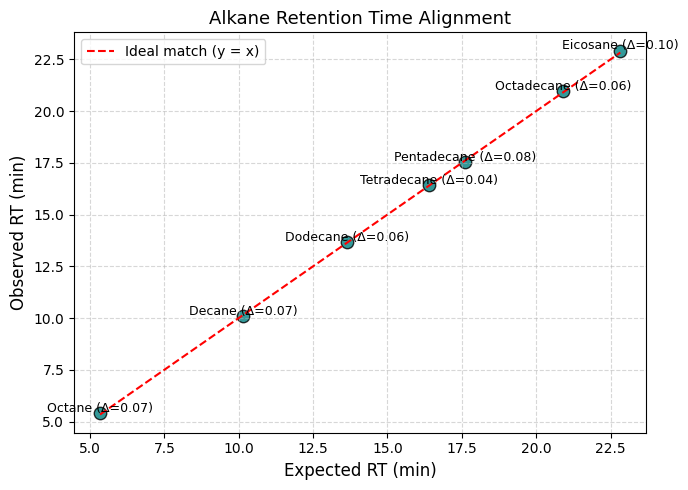

In [0]:

alkanes = pd.DataFrame([
    {"Compound": "Octane",      "tR": 5.34},
    {"Compound": "Decane",      "tR": 10.154},
    {"Compound": "Dodecane",    "tR": 13.626},
    {"Compound": "Tetradecane", "tR": 16.388},
    {"Compound": "Pentadecane", "tR": 17.62},
    {"Compound": "Octadecane",  "tR": 20.906},
    {"Compound": "Eicosane",    "tR": 22.825},
])

# Match alkanes (cleaned_qc_mixed must already exist as a pandas df)
alkane_matches = dp.match_alkanes_to_peaks(
    cleaned_data=cleaned_qc_mixed,
    alkanes_df=alkanes,
    rt_tolerance=0.1
)

# Plot the results
dp.plot_alkane_matches(alkane_matches)


# QC Peak Intensities with Metadata  (by merging the master table and QC GC-MS to have injection order for further analysis)

In [0]:


import os
import pandas as pd

paths_cfg = config["paths"]

# choose one:
# master_table_path = paths_cfg["master_table"]                  # 2024 CSV
master_table_path = paths_cfg["master_table_newharvested"]  # 2025 XLSX

assert os.path.exists(master_table_path), f" Master table not found: {master_table_path}"

ext = os.path.splitext(master_table_path)[1].lower()

if ext == ".csv":
    master_table = pd.read_csv(master_table_path)
elif ext == ".xlsx":
    master_table = pd.read_excel(master_table_path, engine="openpyxl")
elif ext == ".xls":
    master_table = pd.read_excel(master_table_path, engine="xlrd")
else:
    raise ValueError(f"Unsupported master table format: {master_table_path}")

print("Master table path:", master_table_path)
print("Master table shape:", master_table.shape)
print("Master table shape:", master_table.shape)
display(master_table.head())
master_table = master_table.rename(columns={
    "filename": "Filename",
    "sample": "Sample",
    "day": "Day",
    "injection_order": "Injection_order"
})
# ------------------------------------------------------------
# 5) Run merge
# ------------------------------------------------------------
df_qc_mixed = dp.merge_qc_peak_intensities_with_metadata(
    cleaned_qc_mixed=cleaned_qc_mixed,
    master_table=master_table
)

display(df_qc_mixed.head())
print("df_qc_mixed shape:", df_qc_mixed.shape)

# ------------------------------------------------------------
# 5) Run merge
# ------------------------------------------------------------
df_qc_mixed = dp.merge_qc_peak_intensities_with_metadata(
    cleaned_qc_mixed=cleaned_qc_mixed,
    master_table=master_table
)

display(df_qc_mixed.head())
print("df_qc_mixed shape:", df_qc_mixed.shape)


Master table path: /Volumes/bmqg/default_bronze/fatemeh/data/GCMS Steamed 96 set 2025.xlsx
Master table shape: (572, 15)
Master table shape: (572, 15)


#,filename,sample,block,plot,sample_order,sample_date,rep,day,injection_order,blender,tenax,remark,Scan tenax,Check
1759,S962_Blank_B1_D1_T1,Blank,null,null,null,null,1,1,1,null,null,null,null,null
1760,S962_Blank_B1_D1_T2,Blank,null,null,null,null,1,1,2,null,null,null,null,null
1761,S962_QCB_B1_D1_T1,QCB,null,null,null,null,1,1,3,null,null,null,null,null
1762,S962_QC1_B1_D1_T1,QC1,null,null,null,null,1,1,4,null,null,null,null,null
1763,S962_QC2_B1_D1_T1,QC2,null,null,null,null,1,1,5,null,null,null,null,null


 Filtered QC samples found: 4 → ['QC4', 'QC1', 'QC2', 'QC3']
 Final QC dataset shape: (23296, 9)


Peak,tR_best,m/z,SampleCol,Intensity,Filename,Sample,Day,Injection_order
1,1.9215,40,s1 S962_QC4_B1_D3_T1,32640,S962_QC4_B1_D3_T1,QC4,3,79
2,1.9874999999999998,44,s1 S962_QC4_B1_D3_T1,232076,S962_QC4_B1_D3_T1,QC4,3,79
3,2.0345,64,s1 S962_QC4_B1_D3_T1,115162,S962_QC4_B1_D3_T1,QC4,3,79
4,2.1005000000000003,60,s1 S962_QC4_B1_D3_T1,29889,S962_QC4_B1_D3_T1,QC4,3,79
5,2.1825,93,s1 S962_QC4_B1_D3_T1,89611,S962_QC4_B1_D3_T1,QC4,3,79


df_qc_mixed shape: (23296, 9)
 Filtered QC samples found: 4 → ['QC4', 'QC1', 'QC2', 'QC3']
 Final QC dataset shape: (23296, 9)


Peak,tR_best,m/z,SampleCol,Intensity,Filename,Sample,Day,Injection_order
1,1.9215,40,s1 S962_QC4_B1_D3_T1,32640,S962_QC4_B1_D3_T1,QC4,3,79
2,1.9874999999999998,44,s1 S962_QC4_B1_D3_T1,232076,S962_QC4_B1_D3_T1,QC4,3,79
3,2.0345,64,s1 S962_QC4_B1_D3_T1,115162,S962_QC4_B1_D3_T1,QC4,3,79
4,2.1005000000000003,60,s1 S962_QC4_B1_D3_T1,29889,S962_QC4_B1_D3_T1,QC4,3,79
5,2.1825,93,s1 S962_QC4_B1_D3_T1,89611,S962_QC4_B1_D3_T1,QC4,3,79


df_qc_mixed shape: (23296, 9)


# Check QC1–QC4 linearity per day

In [0]:

# --- run
results_df_mix = dp.analyze_qc_intensity_stability(
    alkane_matches=alkane_matches,
    df_qc_mixed=df_qc_mixed
)

# --- make sure R2 is numeric
results_df_mix["R2"] = pd.to_numeric(results_df_mix["R2"], errors="coerce")

# Define threshold for R2
r2_threshold = 0.9

# Keep only stable alkanes
stable_peaks = results_df_mix.loc[results_df_mix["R2"] >= r2_threshold].copy()

# Sort
stable_peaks = stable_peaks.sort_values(["Day", "Compound"])

# Print summary
cols_to_show = [c for c in ["Day","Compound","Peak","tR_best","m/z","R2"] if c in stable_peaks.columns]
print(stable_peaks[cols_to_show])

# Unique stable peaks
stable_peak_ids = sorted(pd.unique(stable_peaks["Peak"].dropna()).tolist()) if "Peak" in stable_peaks.columns else []
print("stable peaks:", stable_peak_ids)


 QC stability analysis complete: 112 regression models fitted.
Mean R² across all models: 0.741
     Day     Compound  Peak  tR_best  m/z        R2
32     1     Dodecane   152  13.4880   57  0.925636
96     1     Eicosane   351  22.8475   43  0.950495
80     1   Octadecane   293  20.9675   57  0.969785
64     1  Pentadecane   213  17.5395   57  0.934850
48     1  Tetradecane   193  16.2535   57  0.944343
..   ...          ...   ...      ...  ...       ...
62    15  Tetradecane   193  16.2535   57  0.918397
111   16     Eicosane   351  22.8475   43  0.946653
95    16   Octadecane   293  20.9675   57  0.929954
79    16  Pentadecane   213  17.5395   57  0.909189
63    16  Tetradecane   193  16.2535   57  0.900413

[70 rows x 6 columns]
stable peaks: [62, 152, 193, 213, 293, 351]


# Visualize QC Injection Stability Using LOESS Smoothing

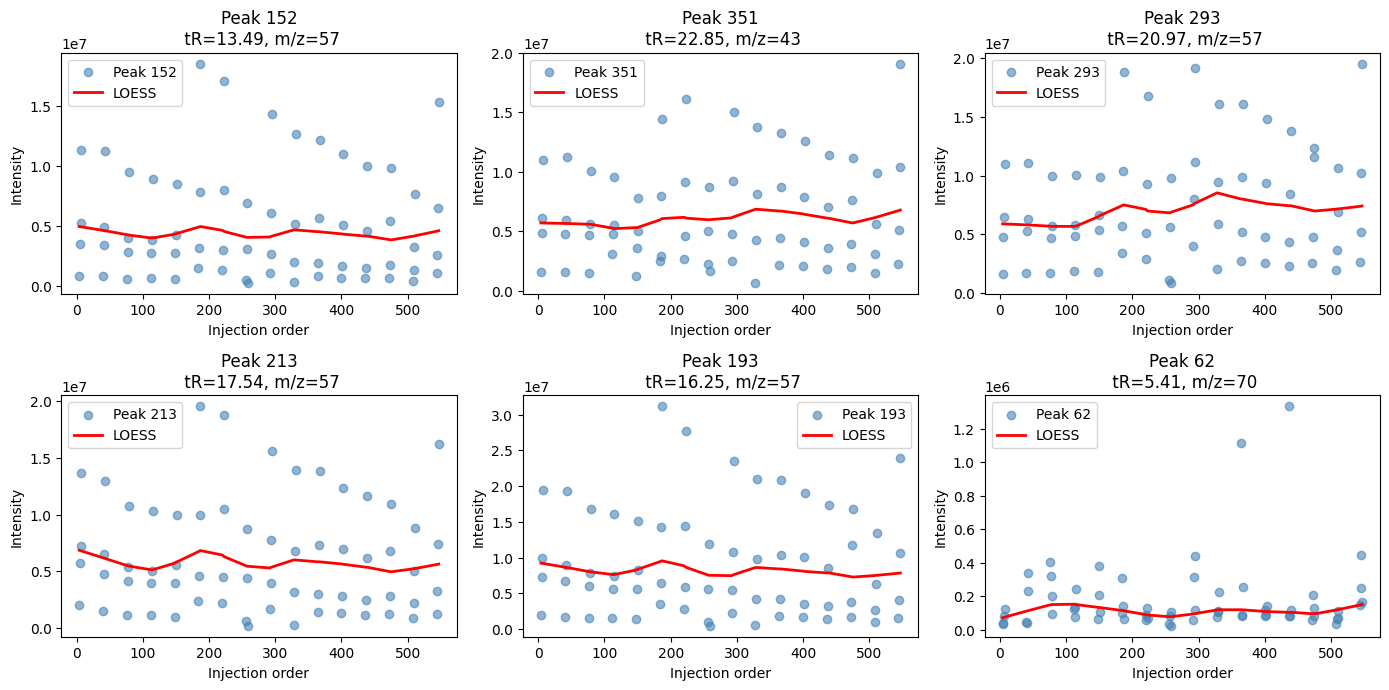

In [0]:

dp.plot_injection_stability_loess(df_qc_mixed, stable_peaks, frac=0.3) 

# Plot QC Injection Stability Using Linear Regression

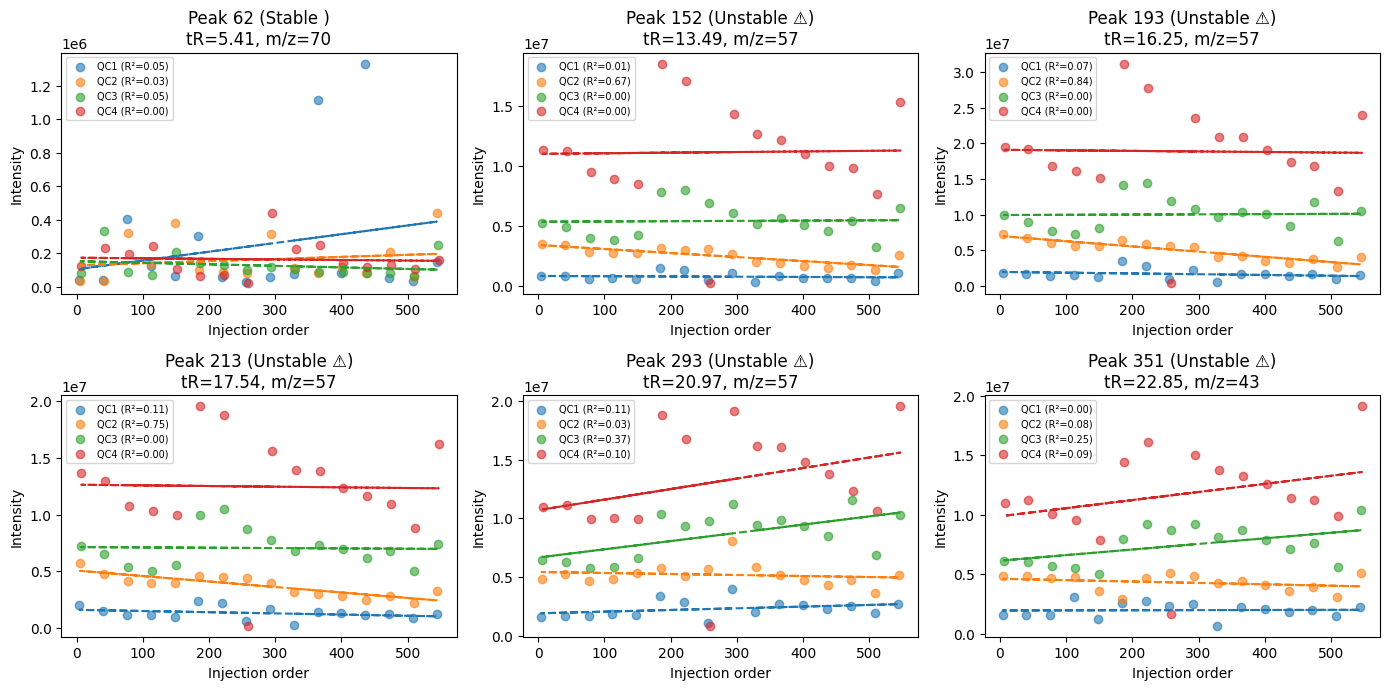

In [0]:

import seaborn as sns
# --- Plot QC Injection Stability Using Linear Regression ---
stable_peaks = [62, 152, 193, 213, 293, 351]

# Call the function
dp.plot_qc_injection_stability_linear(
    df_qc_mixed=df_qc_mixed,  
    stable_peaks=stable_peaks, # list of peak IDs
    qc_levels=["QC1", "QC2", "QC3", "QC4"],  
    max_plots=9                # number of plots per figure
)


# Drift correction

Output dir ready: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested
Stable peaks : [278, 362, 403, 508]
 Removing accidental 'Intensity' column from wide QC table
Alkane QC shape: (128, 10)


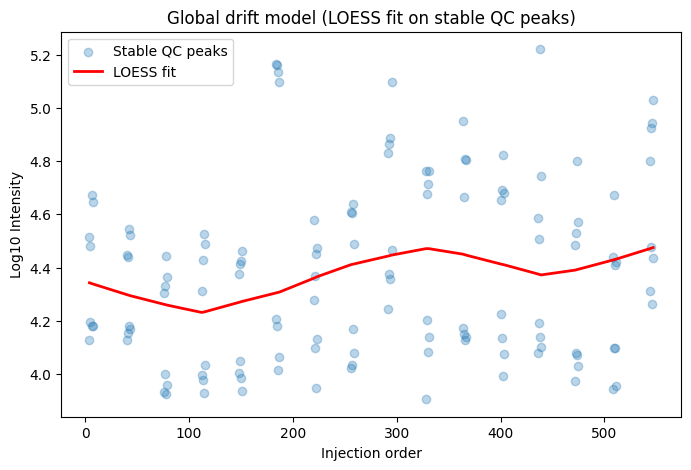

 QC drift correction applied (128 rows)
 Sample drift correction applied (64 samples)


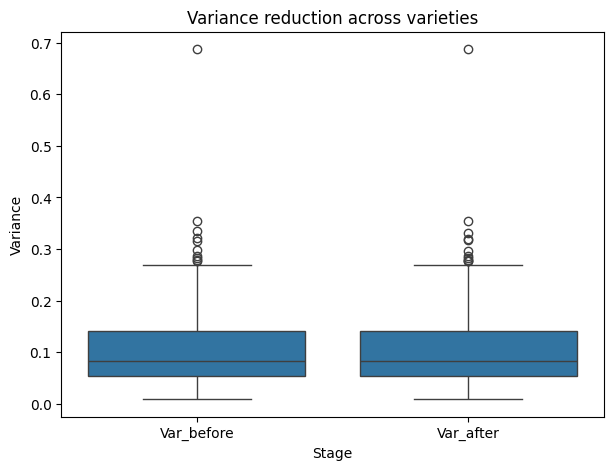

 Results saved to /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested
 Global drift correction complete.

 QC drift correction completed
Corrected QC shape : (364, 67)
QC eval shape     : (2, 3)
Sample eval shape : (364, 3)


Peak,tR_best,m/z,s1 S962_QC4_B1_D3_T1,s10 S962_QC1_B1_D2_T1,s11 S962_QC1_B1_D3_T1,s12 S962_QC1_B1_D4_T1,s13 S962_QC1_B1_D5_T1,s14 S962_QC1_B1_D6_T1,s15 S962_QC1_B1_D7_T1,s16 S962_QC1_B1_D8_T1,s17 S962_QC1_B1_D9_T1,s18 S962_QC2_B1_D10_T1,s19 S962_QC2_B1_D11_T1,s2 S962_QC1_B1_D10_T1,s20 S962_QC2_B1_D12_T1,s21 S962_QC2_B1_D13_T1,s22 S962_QC2_B1_D14_T1,s23 S962_QC2_B1_D15_T1,s24 S962_QC2_B1_D16_T1,s25 S962_QC2_B1_D1_T1,s26 S962_QC2_B1_D2_T1,s27 S962_QC2_B1_D3_T1,s28 S962_QC2_B1_D4_T1,s29 S962_QC2_B1_D5_T1,s3 S962_QC1_B1_D11_T1,s30 S962_QC2_B1_D6_T1,s31 S962_QC2_B1_D7_T1,s32 S962_QC2_B1_D8_T1,s33 S962_QC2_B1_D9_T1,s34 S962_QC3_B1_D10_T1,s35 S962_QC3_B1_D11_T1,s36 S962_QC3_B1_D12_T1,s37 S962_QC3_B1_D13_T1,s38 S962_QC3_B1_D14_T1,s39 S962_QC3_B1_D15_T1,s4 S962_QC1_B1_D12_T1,s40 S962_QC3_B1_D16_T1,s41 S962_QC3_B1_D1_T1,s42 S962_QC3_B1_D2_T1,s43 S962_QC3_B1_D3_T1,s44 S962_QC3_B1_D4_T1,s45 S962_QC3_B1_D5_T1,s46 S962_QC3_B1_D6_T1,s47 S962_QC3_B1_D7_T1,s48 S962_QC3_B1_D8_T1,s49 S962_QC3_B1_D9_T1,s5 S962_QC1_B1_D13_T1,s50 S962_QC4_B1_D10_T1,s51 S962_QC4_B1_D11_T1,s52 S962_QC4_B1_D12_T1,s53 S962_QC4_B1_D13_T1,s54 S962_QC4_B1_D14_T1,s55 S962_QC4_B1_D15_T1,s56 S962_QC4_B1_D16_T1,s57 S962_QC4_B1_D1_T1,s58 S962_QC4_B1_D2_T1,s59 S962_QC4_B1_D4_T1,s6 S962_QC1_B1_D14_T1,s60 S962_QC4_B1_D5_T1,s61 S962_QC4_B1_D6_T1,s62 S962_QC4_B1_D7_T1,s63 S962_QC4_B1_D8_T1,s64 S962_QC4_B1_D9_T1,s7 S962_QC1_B1_D15_T1,s8 S962_QC1_B1_D16_T1,s9 S962_QC1_B1_D1_T1
1,1.9215,40,44004.26580786739,14133.969303474025,31409.711486576245,30216.63536895872,29508.743539172312,57721.01680043547,53775.911771513376,14133.969303474025,14133.969303474025,42918.91910119368,39053.35248011276,15008.672234711039,39546.49060872798,32992.52580261553,35219.60122216835,14133.969303474025,39928.27496636561,33048.202688104364,32117.603316362703,29914.38941916225,29031.513092125268,28617.913371351147,39793.05967303567,55525.75674401919,50912.52908923129,40787.28977105028,14133.969303474025,44875.56393408641,43523.41100078656,40890.68970124376,14133.969303474025,35840.00080332948,49043.376504963715,14133.969303474025,14133.969303474025,34424.21714375665,32403.94158459087,29007.65156977288,29262.17447486467,28267.944376850042,14133.969303474025,53243.00443897762,43332.518821967715,47524.19291519738,33923.12517435728,45845.932509748665,42290.56567924835,39005.62943540802,34551.47859630247,36850.138582912325,37645.52266132403,49942.160513568975,14133.969303474025,14133.969303474025,30392.614096307305,36221.78516096707,30654.096612085166,14133.969303474025,53815.680975434036,41455.41239691606,50928.43677079948,14133.969303474025,14133.969303474025,14133.969303474025
2,1.9874999999999998,44,312875.75233272376,533777.2781017039,224518.02919386004,447322.0114686454,448525.02988724323,779529.0852687639,1027788.3407430166,264546.72717002715,772409.4035368816,639284.9761030155,502317.8493403247,920400.6666957824,582294.7126547195,223265.2992703619,482957.2066416856,410781.07267631363,884305.0299179383,885014.9102079197,223992.08147201056,437397.60663026257,431737.45468226547,490815.6013363933,544003.9288898818,720392.2790388542,272076.0317022919,843682.7765732555,301699.1174726378,267125.76004427735,609343.7367013056,703417.78857545,293119.90595686977,275393.7775393669,472215.5446627359,222213.40382666216,494552.91227483016,246227.0433840097,255224.82577104183,444249.84046577965,233470.07699638384,511093.91841549985,706196.6616994003,295616.41773298447,865500.1618440894,897539.2267526104,474271.6125054295,264024.75636856945,600242.5543840799,229713.87568608447,236818.6439664971,253892.55743970262,446685.7042059156,440988.7657442921,236010.3348968114,604714.6013649489,462012.7553969091,226011.3628010781,447810.1784467706,244895.7692827678,282236.06907390384,267602.99049132434,1199479.947908968,407016.91752523003,893657.752449962,224908.76162237985
3,2.0345,64,155257.06275026588,131882.62827154296,116030.62358879749,137432.42067866062,122260.46938295728,254771.4568463473,246439.80862498487,189134.37423561752

Peak,R2_before,R2_after
278,0.056555216644340045,0.05145823808777872
362,0.12475445686941378,0.01409737547566936


In [0]:
import os

out_dir = "/Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested"
os.makedirs(out_dir, exist_ok=True)

print("Output dir ready:", out_dir)



# =========================================================
# 1) READ FROM CONFIG
# =========================================================

params = config.get("parameters", {})
stable_peaks = params.get("stable_peaks", [278, 362, 403, 508])
loess_frac   = params.get("loess_frac", 0.4)
loess_delta  = params.get("loess_delta", 0.0)

print("Stable peaks :", stable_peaks)


# =========================================================
# 2)  CRITICAL FIX — REMOVE WRONG Intensity COLUMN
# =========================================================

if "Intensity" in cleaned_qc_mixed.columns:
    print(" Removing accidental 'Intensity' column from wide QC table")
    cleaned_qc_mixed = cleaned_qc_mixed.drop(columns=["Intensity"])

# sanity check
assert "Intensity" not in cleaned_qc_mixed.columns, " Intensity column still exists!"

# =========================================================
# 3) FILTER QC DATA FOR STABLE PEAKS
# =========================================================

alkane_qc = (
    df_qc_mixed
    .loc[df_qc_mixed["Peak"].isin(stable_peaks)]
    .copy()
)

# make sure intensity exists here (long-format QC)
assert "Intensity" in alkane_qc.columns, "alkane_qc must contain Intensity"

alkane_qc["Log_Intensity"] = np.log10(
    alkane_qc["Intensity"].astype(float) + 1
)

print("Alkane QC shape:", alkane_qc.shape)

# =========================================================
# 4) GLOBAL DRIFT CORRECTION (MODULE FUNCTION)
# =========================================================

df_corrected, alkan_qc_corrected, qc_eval_df, sample_eval_df = (
    dp.global_drift_correction(
        alkan_qc=alkane_qc,
        cleaned_df_mix=cleaned_qc_mixed,
        stable_peaks=stable_peaks,
        frac=loess_frac,
        delta=loess_delta,
        plot=True,
        save_path="/Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested"
    )
)

# =========================================================
# 5) FINAL CHECKS
# =========================================================

print("\n QC drift correction completed")
print("Corrected QC shape :", df_corrected.shape)
print("QC eval shape     :", qc_eval_df.shape)
print("Sample eval shape :", sample_eval_df.shape)

display(df_corrected.head())
display(qc_eval_df.head())


# Rank QC  Based on Corrected Intensities 

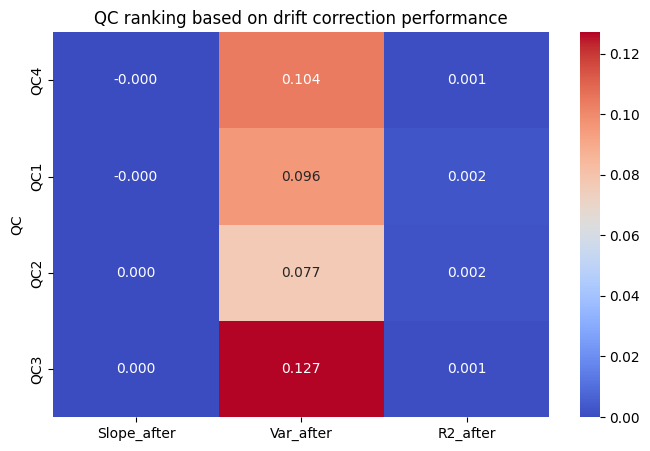

 QC ranking complete.
    QC  Var_before  Var_after  ...   ΔVar(%)    ΔR²(%)     Score
0  QC4    0.112095   0.103899  ...  7.312258 -2.147734  5.114946
1  QC1    0.101546   0.095756  ...  5.701710 -1.488055  4.121776
2  QC2    0.084496   0.076568  ...  9.383411 -5.600434  3.707116
3  QC3    0.133296   0.127116  ...  4.635685 -3.220804  1.364703

[4 rows x 10 columns]


In [0]:


# --- Run QC ranking ---
qc_ranking = dp.rank_qcs(alkane_qc, alkan_qc_corrected)
print(qc_ranking)


# Normalization

 QC4 medians computed for 2 peaks
 Global QC4 median intensity = 23692.4732
 'Sample' column not found — added default value 'AllSamples'.
 Long-format data created: (23296, 6)
 Filled 23168 missing QC4 medians using global QC4 median.
 Normalization by QC4 completed (for averaged varieties).


/Workspace/Users/fatemeh.monfared@hzpc.com/aroma_flavor_project/final_flavor_project/data_prepration.py:1160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melt, x="Stage", y="Log10 Intensity", palette=["#4c72b0", "#dd8452"])


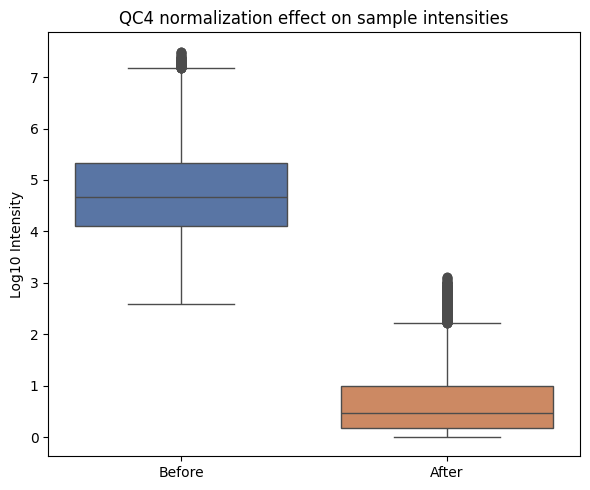

 Boxplot comparison (Before vs After) generated successfully.


In [0]:
from sklearn.linear_model import LinearRegression


df_normalized_wide, df_normalized_long = dp.normalize_with_qc4_meaned_samples(
    df_corrected=df_corrected,
    alkan_qc_corrected=alkan_qc_corrected
)
